<a target="_blank" href="https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/tutorials/fields-2d-tutorial.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# Tutorial: accretion rates (mass flux)


# **LOAD A 2D SIMULATION AND INTERPOLATE**

This tutorial shows how to work with native 2D FARGOpy fields using both Cartesian and polar coordinates.

We will cover:

- Loading a 2D precomputed simulation.
- Defining physical unit conversions.
- Loading 2D fields in polar and Cartesian coordinates.
- Plotting the original loaded mesh.
- Interpolating scalar fields on new polar and Cartesian grids.
- Adding streamlines using the Cartesian velocity field.


In [1]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
%load_ext autoreload
%autoreload 2


Running FARGOpy version 1.2.0.
NOTE: Since alpha versions (<=0.X.X) a major refactor has been done in versions 1.1.X.
Please check the documentation for more information.


## 1. Load a 2D simulation

For this tutorial we use the precomputed 2D Jovian-planet simulation `fargo`.

You can replace this with your own output directory:

```python
sim = fp.Simulation(output_dir='/path/to/your/output')
```


In [2]:
dir = fp.Simulation.download_precomputed("fargo")
sim = fp.Simulation(output_dir=dir)

Precomputed output directory '/tmp/fargo' already exist
Your simulation is now connected with '/home/fargopy/fargo3d/'
Now you are connected with output directory '/tmp/fargo'
Found a variables.par file in '/tmp/fargo', loading properties
Loading variables
84 variables loaded
Simulation in 2 dimensions
Loading domain in polar coordinates:
	Variable phi: 384 [[0, np.float64(-3.1334114227210694)], [-1, np.float64(3.1334114227210694)]]
	Variable r: 128 [[0, np.float64(0.408203125)], [-1, np.float64(2.491796875)]]
	Variable z: 1 [[0, 0.0], [-1, 0.0]]
Number of snapshots in output directory: 51
Planets found in summary.dat
  Name: Jupiter, Initial pos: [1.0, 0.001, 0.0], Mass: 0.001


## 2. Define physical units

If your simulation was compiled with `UNITS=0 RESCALE=0`, you can define the conversion factors from code units to physical units.

For example, if:

- `R0 = 1.0` corresponds to 5.8 AU in CGS units
- `MSTAR = 1.0` corresponds to 1 $M_{\odot}$

then the base length and mass units are:


In [3]:
sim.units('CGS')

UL_cgs = 5.8*sim.AU
UM_cgs = 1*sim.MSUN
G_cgs = 6.67430e-8
sim.set_units(UM=UM_cgs, UL=UL_cgs)

UL= sim.UL
USIGMA= sim.UM/UL**2
UM = sim.UM
UT = np.sqrt(UL**3/(UM*G_cgs))

Units set to CGS.


## 3. Load 2D fields

You can load native 2D fields in either Cartesian or polar coordinates.

To load only a specific region, define a slice in code units. For example:

```python
slice= 'r=[0.8,1.2],phi=[-pi/8,pi/8]'
```

This keeps only the selected radial and azimuthal region. If no slice is provided, the full 2D mesh is loaded by default.


In [4]:
# To load additional fields, add them here, for example:
# ['dust1dens', 'dust1v', 'dust1energy']
fields = ['gasdens', 'gasv', 'gasenergy']

fields_polar = sim.load_field(
    fields=fields,
    snapshot = 10,
    slice = 'r=[0.8,1.2],phi=[-pi/8, pi/8]',
    coords='polar')

fields_cartesian = sim.load_field(
    fields=fields,
    snapshot = 10,
    slice = 'r=[0.8,1.2],phi=[-pi/8, pi/8]',
    coords='cartesian')

## 4. Coordinate convention

The mesh-variable convention follows the FARGO3D coordinate convention.

For native 2D polar outputs:

- Polar coordinates: `var1 = phi`, `var2 = r`
- Cartesian coordinates: `var1 = x`, `var2 = y`

When `coords='cartesian'`, FARGOpy converts the polar disk mesh to Cartesian coordinates for plotting and interpolation.


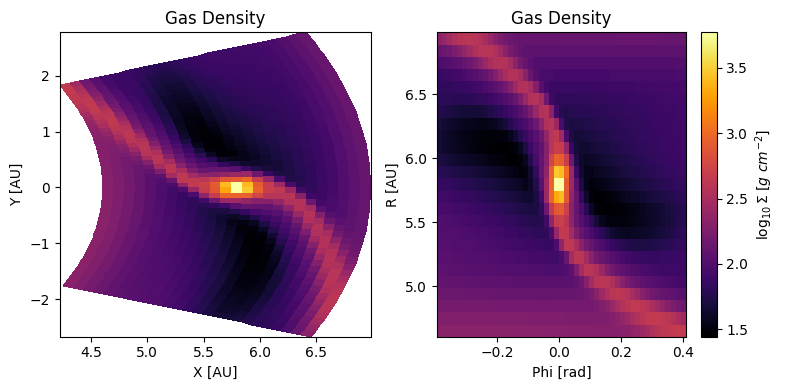

In [5]:
PHI = fields_polar.var1_mesh[0]
R = fields_polar.var2_mesh[0]


X = fields_cartesian.var1_mesh[0]
Y = fields_cartesian.var2_mesh[0]

SIGMA = fields_cartesian.gasdens_mesh[0] # Here SIGMA is the same for both polar and cartesian coordinates

# In physical units

R_units = R*UL/sim.AU

X_units = X*UL/sim.AU
Y_units = Y*UL/sim.AU
SIGMA_units = SIGMA*USIGMA



fig, ax = plt.subplots(1,2, figsize=(8,4))
im = ax[0].pcolormesh(X_units, Y_units, np.log10(SIGMA_units), shading='auto', cmap='inferno')
ax[0].set_xlabel('X [AU]')
ax[0].set_ylabel('Y [AU]')
ax[0].set_title('Gas Density')


im = ax[1].pcolormesh(PHI, R_units, np.log10(SIGMA_units), shading='auto', cmap='inferno')
ax[1].set_xlabel('Phi [rad]')
ax[1].set_ylabel('R [AU]')
ax[1].set_title('Gas Density')
fig.colorbar(im, ax=ax[1], orientation='vertical', label=r'$\log_{10}{\Sigma} ~[g~cm^{-2}]$')



plt.tight_layout()
plt.show()


## 5. Plot the original loaded mesh

The loaded fields contain the original mesh values from the selected snapshot and slice. No interpolation has been applied yet.

Here we plot the same density field in two representations:

- Cartesian plane: `x`, `y`
- Native polar plane: `phi`, `r`


## 6. Interpolate a 2D field in Cartesian and polar coordinates

To plot the data on a new grid, first create a meshgrid in the coordinate system in which you want to evaluate the field.

For Cartesian interpolation:

- `var1 = x`
- `var2 = y`

For polar interpolation:

- `var1 = phi`
- `var2 = r`

The same loaded field can be evaluated on either grid, provided that the field was loaded with the corresponding coordinate representation.


In [6]:
#Grid resolution for interpolation
RES1 = 720
RES2 = 720
phis = np.linspace(PHI.min(), PHI.max(), RES1)
rs = np.linspace(R.min(), R.max(), RES2)
PHI, R = np.meshgrid(phis, rs)

xs = np.linspace(X.min(), X.max(), RES1)
ys = np.linspace(Y.min(), Y.max(), RES2)
X, Y = np.meshgrid(xs, ys)


dens_polar_interp = fields_polar.evaluate(
    field='gasdens',
    var1=PHI,
    var2=R,
    snapshot=10,
)

dens_cartesian_interp = fields_cartesian.evaluate(
    field='gasdens',
    var1=X,
    var2=Y,
    snapshot=10,
)


# In physical units
R_units = R*UL/sim.AU
X_units = X*UL/sim.AU
Y_units = Y*UL/sim.AU
SIGMA_units_cartesian = dens_cartesian_interp*USIGMA
SIGMA_units_polar = dens_polar_interp*USIGMA





Using griddata interpolation...
Using griddata interpolation...


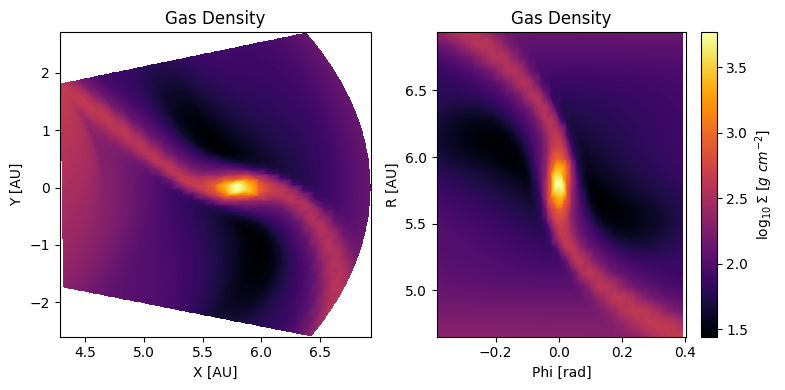

In [7]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
im = ax[0].pcolormesh(X_units, Y_units, np.log10(SIGMA_units_cartesian), shading='auto', cmap='inferno')
ax[0].set_xlabel('X [AU]')
ax[0].set_ylabel('Y [AU]')
ax[0].set_title('Gas Density')


im = ax[1].pcolormesh(PHI, R_units, np.log10(SIGMA_units_polar), shading='auto', cmap='inferno')
ax[1].set_xlabel('Phi [rad]')
ax[1].set_ylabel('R [AU]')
ax[1].set_title('Gas Density')
fig.colorbar(im, ax=ax[1], orientation='vertical', label=r'$\log_{10}{\Sigma} ~[g~cm^{-2}]$')



plt.tight_layout()
plt.show()

## 7. Add streamlines

To add streamlines, load the velocity field in Cartesian coordinates and then interpolate it on a regular Cartesian grid.

For a native 2D disk, use the `vx` and `vy` components of the interpolated velocity field.


The streamplot requires a regular Cartesian grid. The cell below:

1. Extracts the Cartesian mesh from `fields_cartesian`.
2. Interpolates `gasv` on a regular `x-y` grid.
3. Uses `vx` and `vy` to draw streamlines.
4. Colors the background by the velocity magnitude.


Using griddata interpolation...
Using griddata interpolation...
Using griddata interpolation...


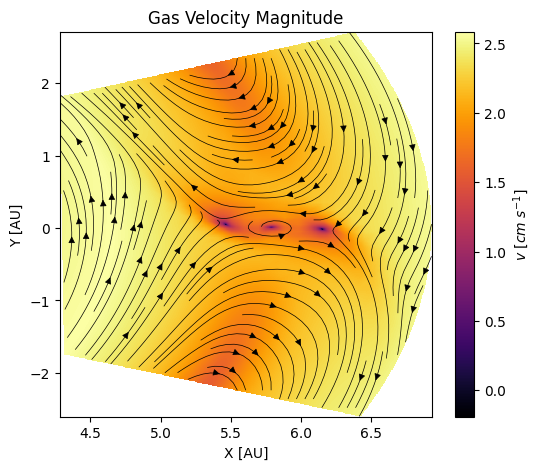

In [8]:
X = fields_cartesian.var1_mesh[0]
Y = fields_cartesian.var2_mesh[0]



# here we load the gas velocity field
gasv = fields_cartesian.gasv_mesh[0]

# if only want the original gas velocity field without interpolation, you can use the code below
vx = gasv[0]
vy = gasv[1]
vmag = np.sqrt(vx**2 + vy**2)

# create a grid for interpolation is necesary for streamplot
xs = np.linspace(X.min(), X.max(), RES1)
ys = np.linspace(Y.min(), Y.max(), RES2)
X, Y = np.meshgrid(xs, ys)


gasv_interp =fields_cartesian.evaluate(
    field='gasv',
    var1=X,
    var2=Y,
    snapshot=10,
)

vx = gasv_interp[0]
vy = gasv_interp[1]
vmag = np.sqrt(vx**2 + vy**2)

# physical units
X_units = X*UL/sim.AU
Y_units = Y*UL/sim.AU
UV = UL/UT * 1e-3  # velocity unit in km/s

fig, ax = plt.subplots(figsize=(6,5))
im = ax.pcolormesh(X_units, Y_units, np.log10(vmag*UV), shading='auto', cmap='inferno')
ax.streamplot(X_units, Y_units, vx*UV, vy*UV, color='k', density=1.5, linewidth=0.5,cmap='viridis_r')
ax.set_xlabel('X [AU]')
ax.set_ylabel('Y [AU]')
ax.set_title('Gas Velocity Magnitude')
fig.colorbar(im, ax=ax, orientation='vertical', label=r'${v} ~[cm~s^{-1}]$')   




---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
